In [4]:
using BoundaryValueDiffEq
using Plots

# BVP general boundaries

In [8]:
const g = 9.81
L = 1.0
tspan = (0.0, pi / 2)
function simplependulum!(du, u, p, t)
    θ = u[1]
    dθ = u[2]
    du[1] = dθ
    du[2] = -(g / L) * sin(θ)
end

simplependulum! #(generic function with 1 method)


function bc1!(residual, u, p, t)
    residual[1] = u[end ÷ 2][1] + pi / 2 # the solution at the middle of the time span should be -pi/2
    residual[2] = u[end][1] - pi / 2 # the solution at the end of the time span should be pi/2
end

bc1! (generic function with 1 method)

## mirk method

In [14]:
bvp1 = BVProblem(simplependulum!, bc1!, [pi / 2, pi / 2], tspan)
sol1 = solve(bvp1, MIRK4(), dt = 0.05)
plot(sol1)

ForwardDiff.DualMismatchError{DataType, DataType}: Cannot determine ordering of Dual tags ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, ForwardDiff.Dual{Nothing, Float64, 2}} and Nothing

## Shooting method

- you need to use a difference indexing method!

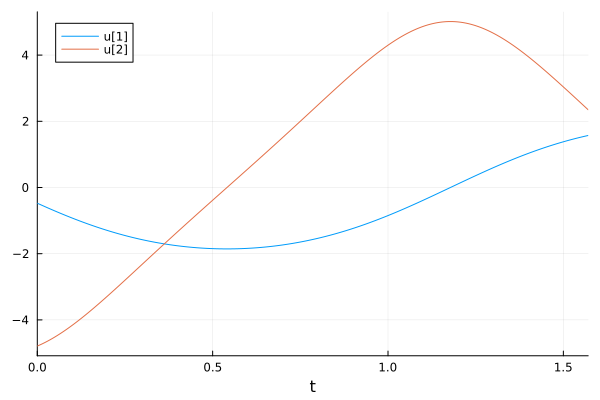

In [16]:
using OrdinaryDiffEq
u₀_2 = [-1.6, -1.7] # the initial guess
function bc3!(residual, sol, p, t)
    residual[1] = sol(pi / 4)[1] + pi / 2 # use the interpolation here, since indexing will be wrong for adaptive methods
    residual[2] = sol(pi / 2)[1] - pi / 2
end
bvp3 = BVProblem(simplependulum!, bc3!, u₀_2, tspan)
sol3 = solve(bvp3, Shooting(Vern7()))
plot(sol3)

# Two point BVP

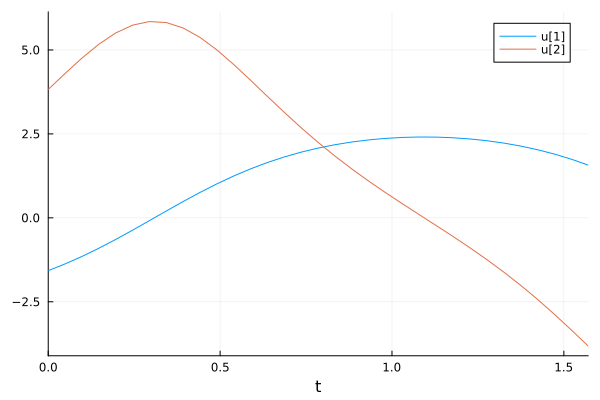

In [17]:
function bc2a!(resid_a, u_a, p) # u_a is at the beginning of the time span
    resid_a[1] = u_a[1] + pi / 2 # the solution at the beginning of the time span should be -pi/2
end
function bc2b!(resid_b, u_b, p) # u_b is at the ending of the time span
    resid_b[1] = u_b[1] - pi / 2 # the solution at the end of the time span should be pi/2
end
bvp2 = TwoPointBVProblem(simplependulum!, (bc2a!, bc2b!), [pi / 2, pi / 2], tspan;
    bcresid_prototype = (zeros(1), zeros(1)))
sol2 = solve(bvp2, MIRK4(), dt = 0.05)
plot(sol2)

# complex example

In [25]:
function ShapeIntegrator!(du,u,p,t)
    du[1] = 13 * u[3]
    du[2] = 0.1 * u[1]
    du[3] = 5 * u[2]
    du[4] = 0.01 * u[4]
    du[5] = 0 #omega
    du[6] = 0 #sigma
end

ShapeIntegrator! (generic function with 1 method)

In [33]:
function ShapeIntegrator!(du,u,p,t)
    # psi,u,gamma,x

    # k = 1.0
    # omega, sigma, u0 = p
    omega = u[5]
    sigma = u[6]

    du[1] = omega * u[2]

    a1 = -u[2] / u[4] * cos(u[1])
    a2 = (sin(u[1]) * cos(u[1])) / u[4]^2
    a3 = (sin(u[1]) * u[3]) / (2π * u[4])
    du[2] = omega * (a1 + a2 + a3)

    b1 = π *(u[2]^2 - sin(u[1])^2 / u[4]^2)
    b2 = 2π * sigma
    du[3] = omega * (b1 + b2)

    du[4] = omega * cos(u[1])

    du[5] = 0 #omega
    du[6] = 0 #sigma
end

ShapeIntegrator! (generic function with 1 method)

In [27]:
Rparticle = 3
Rvesicle = 30
rpa = Rparticle / Rvesicle

phi = pi / 6.0

# Boundary conditions
psistar = pi + phi
ustar = 1/rpa
xstar = rpa*sin(phi)

p = [psistar, ustar, xstar]

3-element Vector{Float64}:
  3.665191429188092
 10.0
  0.049999999999999996

In [28]:
# there is no need to pass additional args because star variables are defined globallu
function bc1!(residual, u, p, t)
    residual[1] = u[end][1] - psistar
    residual[2] = u[end][2] - ustar
    # residual[4] = u[end][4] - xstar
    residual[4] = u[end][4] - xstar
end

bc1! (generic function with 1 method)

In [34]:
function bc1!(residual, u, p, t)
    residual[1] = u[end][1] - 0
    residual[2] = u[end][2] - 0
    residual[3] = u[end][3] - 0
end

bc1! (generic function with 1 method)

In [35]:
function bc1!(residual, u, p, t)
    residual[1] = 1
    residual[2] = 0.2
    residual[3] = 1
end

bc1! (generic function with 1 method)

In [36]:
# init = [1.0;0.0;0.0;0.0]
# tspan = (0.0,1)
# p = [omega;sigma;u0]
# prob = ODEProblem(ShapeIntegrator!,init,tspan,p)

In [37]:
# # Test that it worked
# using OrdinaruDiffEq
# sol = solve(prob,Tsit5())
# using Plots; plot(sol,vars=(1,2,3))

In [38]:
s_span = [0,1.0]

omega0 = 3
sigma0 = 0.0
u0 = 1.0
init = [0.035,u0,0.004, 0.035,omega0,sigma0]


bvp2 = BVProblem(ShapeIntegrator!, bc1!, init, s_span,p)

MethodError: MethodError: objects of type Vector{Float64} are not callable
Use square brackets [] for indexing an Array.

In [82]:
sol1 = solve(bvp1, MIRK4(), dt = 0.01)
plot(sol1)

ErrorException: Parameters were indexed but the parameters are `nothing`. You likely forgot to pass in parameters to the DEProblem!